# Evaluate the CheckAMG-PST model on each test dataset split

Load the saved per-protein predictions from `train_pst.ipynb`, then evaluate the best CheckAMG-PST model on each test dataset split.

In [1]:
! pip install polars pandas matplotlib tables pyfastatools seaborn torch torchmetrics uv --quiet

## Load predictions

In [1]:
from pathlib import Path
import polars as pl

PST_TABLES_OUTDIR = Path("./tables/pst")
PST_TABLES_OUTDIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_PARQUET = PST_TABLES_OUTDIR.joinpath("model_predictions_with_labels.parquet")

CHECKAMG_FILES_DIR = Path("../CheckAMG/files")
OUTPUT_THRESHOLDS_FILE = CHECKAMG_FILES_DIR / "pst_thresholds.json"

model_predictions_with_labels = pl.read_parquet(PREDICTIONS_PARQUET)
model_predictions_with_labels

Contig,sequence,frame,gene_number,viral,AVG,AVG-like prob,Viral prob,model,dataset,eff_avg_prob,eff_avg_label
str,str,i64,i64,bool,bool,f64,f64,str,str,f64,bool
"""1001585.SAMN02603190.CP002620~…","""1001585.SAMN02603190.CP002620~…",-1,1,false,true,0.9537,0.0,"""checkAMG-PST_TL-P__large_5""","""test_equal_pos""",0.0,false
"""1001585.SAMN02603190.CP002620~…","""1001585.SAMN02603190.CP002620~…",1,2,false,true,1.0,0.0,"""checkAMG-PST_TL-P__large_5""","""test_equal_pos""",0.0,false
"""1001585.SAMN02603190.CP002620~…","""1001585.SAMN02603190.CP002620~…",1,3,false,false,0.0,0.0,"""checkAMG-PST_TL-P__large_5""","""test_equal_pos""",0.0,false
"""1001585.SAMN02603190.CP002620~…","""1001585.SAMN02603190.CP002620~…",-1,4,false,false,0.0,0.0,"""checkAMG-PST_TL-P__large_5""","""test_equal_pos""",0.0,false
"""1001585.SAMN02603190.CP002620~…","""1001585.SAMN02603190.CP002620~…",-1,5,false,false,0.0,0.0,"""checkAMG-PST_TL-P__large_5""","""test_equal_pos""",0.0,false
…,…,…,…,…,…,…,…,…,…,…,…
"""fragment_9959""","""fragment_9959_10""",1,10,true,false,0.0,0.9072,"""checkAMG-PST_TL-P__large_5""","""test_virus_enriched""",0.0,false
"""fragment_9959""","""fragment_9959_11""",1,11,true,false,0.0,0.9487,"""checkAMG-PST_TL-P__large_5""","""test_virus_enriched""",0.0,false
"""fragment_9959""","""fragment_9959_12""",1,12,true,false,0.0,0.9493,"""checkAMG-PST_TL-P__large_5""","""test_virus_enriched""",0.0,false


## Threshold selection and evaluation helpers

In [2]:
from torchmetrics.functional import classification as C
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import polars.selectors as cs

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# torchmetrics.functional.classification is already imported as C.

DATASET_DISPLAY = {
    "test_equal_pos":        "Equal viral/nonviral",
    "test_equal_source":     "Equal viral/MGE/host",
    "test_half_virus_host":  "Half viral/host",
    "test_host_enriched":    "Host enriched",
    "test_input":            "Training distribution",
    "test_mge_enriched":     "MGE enriched",
    "test_near_all_host":    "Near all host",
    "test_near_all_virus":   "Near all virus",
    "test_provirus":         "Integrated proviruses",
    "test_virus_enriched":   "Virus enriched",
}

THRESHOLD_GRID_STEP = 0.001
THRESHOLD_GRID = np.arange(0.0, 1.0 + 1e-9, THRESHOLD_GRID_STEP)

CONFIDENCE_LEVELS = ["Very High Confidence", "High Confidence", "Medium Confidence", "Low Confidence"]
CONFIDENCE_MARKERS = {
    "Very High Confidence": ("D", 90),   # diamond
    "High Confidence":      ("o", 80),   # circle
    "Medium Confidence":    ("s", 65),   # square
    "Low Confidence":       ("v", 75),   # down triangle
}

# Reliability / calibration defaults (matches lgbm/_compute_reliability)
RELIABILITY_N_BINS = 15
RELIABILITY_STRATEGY = "uniform"   # "uniform" or "quantile"

# Figure layout: reserve right portion for the Dataset legend so it doesn't get clipped.
DEFAULT_FIGSIZE = (11, 5)
AXES_RIGHT = 0.65   # axes occupies left 65% of figure; right 35% for legend


def _iter_dataset_slices(df, prob_col, label_col):
    """Yield (display_name, probs:Tensor[float], labels:Tensor[long]); one entry per
    `dataset` value."""
    for key, sub in df.partition_by("dataset", as_dict=True).items():
        ds_key = key[0] if isinstance(key, tuple) else key
        name = DATASET_DISPLAY.get(ds_key, ds_key)
        p = sub.get_column(prob_col).to_torch().float()
        l = sub.get_column(label_col).to_torch().to(torch.long)
        yield name, p, l


def _per_split_arrays(df, prob_col, label_col):
    out = {}
    for key, sub in df.partition_by("dataset", as_dict=True).items():
        k = key[0] if isinstance(key, tuple) else key
        out[k] = (
            sub.get_column(prob_col).to_numpy(),
            sub.get_column(label_col).to_numpy().astype(np.int64),
        )
    return out


def _metrics_at_threshold(probs, labels, t):
    pred = probs >= t
    tp = int(((labels == 1) & pred).sum())
    fp = int(((labels == 0) & pred).sum())
    fn = int(((labels == 1) & ~pred).sum())
    tn = int(((labels == 0) & ~pred).sum())
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr       = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    return precision, recall, fpr, recall  # recall == tpr


def _precision_count_on_grid(probs, labels, grid):
    """Vectorized precision and prediction-count at every threshold in `grid` (prediction
    made when prob >= t). Suffix sums over sorted probs evaluate the whole grid in one
    pass instead of rescanning the array per threshold."""
    probs = np.asarray(probs, dtype=float)
    labels = np.asarray(labels, dtype=np.int64)
    order = np.argsort(probs, kind="stable")
    sp = probs[order]
    sl = labels[order]
    n = sp.size
    suffix_pos = np.zeros(n + 1, dtype=np.int64)
    suffix_pos[:-1] = np.cumsum(sl[::-1])[::-1]
    idx = np.searchsorted(sp, grid, side="left")  # count of probs < t
    count = n - idx
    tp = suffix_pos[idx]
    with np.errstate(divide="ignore", invalid="ignore"):
        prec = np.where(count > 0, tp / count, 0.0)
    return prec, count


def _find_threshold(precomp, eligible_keys, min_precision, grid=THRESHOLD_GRID, strict=False):
    """Smallest grid threshold whose precision meets `min_precision` (strict '>' when
    `strict`) on every eligible split, requiring at least one prediction there. Returns
    None if none qualifies. `precomp` maps split -> (prec, count) from
    `_precision_count_on_grid`."""
    ok = np.ones(grid.size, dtype=bool)
    for k in eligible_keys:
        prec, count = precomp[k]
        cond = (prec > min_precision) if strict else (prec >= min_precision)
        ok &= cond & (count > 0)
    nz = np.nonzero(ok)[0]
    return float(grid[nz[0]]) if nz.size else None


def _max_worstcase_precision_threshold(precomp, eligible_keys, lower_bound, grid=THRESHOLD_GRID):
    """Fallback for when a precision floor is unreachable: among thresholds above
    `lower_bound` that still make at least one prediction on every eligible split, return
    the one maximizing the worst-case (minimum across splits) precision. Ties break toward
    the smallest such threshold for more coverage. Returns (threshold, worst_case_precision)
    or (None, None) if no threshold above `lower_bound` is feasible."""
    min_prec = np.full(grid.size, np.inf)
    feasible = grid > lower_bound
    for k in eligible_keys:
        prec, count = precomp[k]
        min_prec = np.minimum(min_prec, prec)
        feasible &= count > 0
    idxs = np.nonzero(feasible)[0]
    if idxs.size == 0:
        return None, None
    best = float(min_prec[idxs].max())
    achieving = idxs[min_prec[idxs] >= best - 1e-12]
    return float(grid[achieving[0]]), best


def _target_key(target):
    if target.startswith("AVG"):
        return "AVG"
    if target == "viral":
        return "viral"
    raise ValueError(f"No precision floors defined for target {target!r}.")


def _floors_for(target):
    return PRECISION_FLOORS[_target_key(target)]


def _excluded_for(target):
    return EXCLUDED_FLOOR_DATASETS[_target_key(target)]


def build_confidence_points(df, prob_col, label_col, target):
    """Pick Very High / High / Medium thresholds for `target` from the per-tier precision
    floors in PRECISION_FLOORS, enforced on every split except EXCLUDED_FLOOR_DATASETS.
    Each tier is normally the smallest threshold meeting its floor (>=) on all eligible
    splits. When a floor is unreachable, the tier instead uses the threshold that maximizes
    the worst-case precision across eligible splits, kept strictly above the next-lower
    tier's threshold (tiers are resolved loosest-first so that bound is known). Low
    Confidence is t=0.0. Returns thresholds and per-(dataset, confidence) operating points
    (precision, recall, fpr, tpr)."""
    arrays = _per_split_arrays(df, prob_col, label_col)
    eligible = [k for k in arrays if k not in _excluded_for(target)]
    floors = _floors_for(target)

    precomp = {k: _precision_count_on_grid(arrays[k][0], arrays[k][1], THRESHOLD_GRID)
               for k in eligible}

    # Resolve loosest-first so each tier's fallback can stay above the next-lower tier.
    resolved = {}
    prev_t = 0.0  # Low Confidence threshold
    for tier in ("Medium Confidence", "High Confidence", "Very High Confidence"):
        floor = floors[tier]
        t = _find_threshold(precomp, eligible, floor)
        if t is not None and t > prev_t:
            resolved[tier] = float(t)
        else:
            ft, wc = _max_worstcase_precision_threshold(precomp, eligible, prev_t)
            reason = "unreachable" if t is None else f"not above lower tier (t={prev_t:.4f})"
            if ft is None:
                ft = prev_t
                print(f"[{target}] {tier}: precision floor >= {floor:.2f} {reason}; no "
                      f"threshold above {prev_t:.4f} makes predictions, collapsing to t={ft:.4f}.")
            else:
                print(f"[{target}] {tier}: precision floor >= {floor:.2f} {reason}; using "
                      f"highest-attainable-precision t={ft:.4f} (worst-case precision "
                      f"{wc:.3f} across eligible splits).")
            resolved[tier] = float(ft)
        prev_t = resolved[tier]

    # Round to the grid precision so stored cutoffs are exact (avoids float noise like
    # 0.9500000000000001 that would misclassify a probability sitting exactly on a cutoff).
    thresholds = {
        "Very High Confidence": round(resolved["Very High Confidence"], 6),
        "High Confidence":      round(resolved["High Confidence"], 6),
        "Medium Confidence":    round(resolved["Medium Confidence"], 6),
        "Low Confidence":       0.0,
    }

    points: dict[tuple[str, str], tuple[float, float, float, float]] = {}
    for k, (p, y) in arrays.items():
        name = DATASET_DISPLAY.get(k, k)
        for conf, t in thresholds.items():
            points[(name, conf)] = _metrics_at_threshold(p, y, t)
    return thresholds, points


def _compute_reliability(y_prob, y_true, n_bins=RELIABILITY_N_BINS, strategy=RELIABILITY_STRATEGY):
    """Port of lgbm's _compute_reliability. Returns prob_pred (bin mean of probs),
    prob_true (bin mean of labels = observed positive fraction), bin_counts, and ECE."""
    y_prob = np.asarray(y_prob, dtype=float)
    y_true = np.asarray(y_true, dtype=np.int64)
    n = y_prob.size
    if n == 0:
        return {
            "prob_pred": np.array([], dtype=float),
            "prob_true": np.array([], dtype=float),
            "bin_counts": np.array([], dtype=np.int64),
            "ece": float("nan"),
        }
    if strategy == "quantile":
        q = np.linspace(0.0, 1.0, n_bins + 1)
        edges = np.unique(np.quantile(y_prob, q))
        if edges.size < 3:
            edges = np.linspace(0.0, 1.0, n_bins + 1)
    else:
        edges = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.digitize(y_prob, edges, right=True) - 1
    idx = np.clip(idx, 0, edges.size - 2)
    pp, pt, cnt = [], [], []
    ece_num = 0.0
    for b in range(edges.size - 1):
        mask = idx == b
        c = int(mask.sum())
        if c == 0:
            continue
        conf = float(y_prob[mask].mean())
        acc = float(y_true[mask].mean())
        pp.append(conf)
        pt.append(acc)
        cnt.append(c)
        ece_num += abs(acc - conf) * c
    return {
        "prob_pred": np.asarray(pp, dtype=float),
        "prob_true": np.asarray(pt, dtype=float),
        "bin_counts": np.asarray(cnt, dtype=np.int64),
        "ece": float(ece_num / n),
    }


def _add_marker_legend(ax, loc):
    handles = [
        Line2D([0], [0], marker=m, linestyle="None", color="black",
               markerfacecolor="lightgray", markersize=8, label=conf)
        for conf, (m, _s) in CONFIDENCE_MARKERS.items()
    ]
    return ax.legend(handles=handles, loc=loc, title="Confidence Level",
                     frameon=True, framealpha=0.9)


def _finalize_with_dual_legends(fig, ax, ds_handles_labels=None, marker_legend_loc=None):
    """Place the Dataset legend outside the axes (anchored to the figure so it
    isn't clipped by tight-layout), optionally an inner Confidence Level legend."""
    if ds_handles_labels is None:
        handles, labels = ax.get_legend_handles_labels()
    else:
        handles, labels = ds_handles_labels
    # Dataset legend lives at the figure level so subplots_adjust can reserve its space.
    fig.legend(handles, labels, loc="center left",
               bbox_to_anchor=(AXES_RIGHT + 0.02, 0.5),
               title="Dataset", frameon=False)
    if marker_legend_loc is not None:
        _add_marker_legend(ax, loc=marker_legend_loc)
    fig.subplots_adjust(left=0.08, right=AXES_RIGHT, top=0.92, bottom=0.12)


def plot_pr_curves(df, prob_col, label_col, title, points=None, figsize=DEFAULT_FIGSIZE, floor_lines=None):
    rows = []
    for name, p, l in _iter_dataset_slices(df, prob_col, label_col):
        prec, rec, _ = C.binary_precision_recall_curve(p, l)
        ap = C.binary_average_precision(p, l).item()
        rows.append((name, ap, prec.numpy(), rec.numpy()))
    rows.sort(key=lambda r: -r[1])

    fig, ax = plt.subplots(figsize=figsize)
    # Reference lines at the per-tier precision floors used for threshold selection.
    for val, st in zip(floor_lines or (), ("--", ":", "-.")):
        ax.axhline(val, color="gray", linestyle=st, linewidth=1.5, alpha=0.5, zorder=0)
    handles, labels = [], []
    for name, ap, prec, rec in rows:
        line, = ax.plot(rec, prec, label=f"{name} (AUPRC={ap:.3f})", linewidth=1.5)
        handles.append(line)
        labels.append(line.get_label())
        if points is not None:
            for conf, (marker, size) in CONFIDENCE_MARKERS.items():
                key = (name, conf)
                if key not in points:
                    continue
                m_prec, m_rec, _f, _t = points[key]
                ax.scatter(m_rec, m_prec, marker=marker, s=size,
                           color=line.get_color(), edgecolor="black",
                           linewidth=0.8, zorder=5)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_title(title)
    _finalize_with_dual_legends(
        fig, ax, ds_handles_labels=(handles, labels),
        marker_legend_loc="lower left" if points is not None else None,
    )
    return fig, ax


def plot_roc_curves(df, prob_col, label_col, title, points=None, figsize=DEFAULT_FIGSIZE):
    rows = []
    for name, p, l in _iter_dataset_slices(df, prob_col, label_col):
        fpr, tpr, _ = C.binary_roc(p, l)
        auc = C.binary_auroc(p, l).item()
        rows.append((name, auc, fpr.numpy(), tpr.numpy()))
    rows.sort(key=lambda r: -r[1])

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot([0, 1], [0, 1], linestyle="--", color="lightgray", linewidth=1)
    handles, labels = [], []
    for name, auc, fpr, tpr in rows:
        line, = ax.plot(fpr, tpr, label=f"{name} (AUROC={auc:.3f})", linewidth=1.5)
        handles.append(line)
        labels.append(line.get_label())
        if points is not None:
            for conf, (marker, size) in CONFIDENCE_MARKERS.items():
                key = (name, conf)
                if key not in points:
                    continue
                _p, _r, m_fpr, m_tpr = points[key]
                ax.scatter(m_fpr, m_tpr, marker=marker, s=size,
                           color=line.get_color(), edgecolor="black",
                           linewidth=0.8, zorder=5)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_title(title)
    _finalize_with_dual_legends(
        fig, ax, ds_handles_labels=(handles, labels),
        marker_legend_loc="lower right" if points is not None else None,
    )
    return fig, ax


def plot_reliability_curves(df, prob_col, label_col, title,
                            n_bins=RELIABILITY_N_BINS, strategy=RELIABILITY_STRATEGY,
                            figsize=DEFAULT_FIGSIZE):
    """Calibration / reliability diagram: predicted probability (bin mean) on x,
    observed positive fraction in that bin on y. One line per split,
    sorted by ascending ECE. Dashed y=x diagonal is the perfect-calibration reference."""
    rows = []
    for name, p, l in _iter_dataset_slices(df, prob_col, label_col):
        rel = _compute_reliability(p.numpy(), l.numpy(), n_bins=n_bins, strategy=strategy)
        rows.append((name, rel["ece"], rel["prob_pred"], rel["prob_true"]))
    rows.sort(key=lambda r: r[1])  # lower ECE first (better calibration)

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot([0, 1], [0, 1], linestyle="--", color="lightgray", linewidth=1)
    handles, labels = [], []
    for name, ece, pp, pt in rows:
        if pp.size == 0:
            continue
        line, = ax.plot(pp, pt, marker="o", linewidth=1.2,
                        label=f"{name} (ECE={ece:.3f})")
        handles.append(line)
        labels.append(line.get_label())
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Observed fraction of positives")
    ax.set_title(title)
    _finalize_with_dual_legends(fig, ax, ds_handles_labels=(handles, labels))
    return fig, ax


In [4]:
def pr_points_df(df, prob_col, label_col, target, marker_points=None):
    rows = []
    for name, p, l in _iter_dataset_slices(df, prob_col, label_col):
        prec, rec, _ = C.binary_precision_recall_curve(p, l)
        prec = prec.numpy()
        rec = rec.numpy()
        for i, (r, pr) in enumerate(zip(rec, prec)):
            rows.append({
                "dataset": name, "target": target, "type": "curve",
                "idx": i, "recall": float(r), "precision": float(pr),
                "confidence": None,
            })
    if marker_points is not None:
        for (name, conf), (m_prec, m_rec, _f, _t) in marker_points.items():
            rows.append({
                "dataset": name, "target": target, "type": "point",
                "idx": None, "recall": float(m_rec), "precision": float(m_prec),
                "confidence": conf,
            })
    return pl.DataFrame(rows, schema={
        "dataset": pl.Utf8, "target": pl.Utf8, "type": pl.Utf8,
        "idx": pl.Int64, "recall": pl.Float64, "precision": pl.Float64,
        "confidence": pl.Utf8,
    })


def roc_points_df(df, prob_col, label_col, target, marker_points=None):
    rows = []
    for name, p, l in _iter_dataset_slices(df, prob_col, label_col):
        fpr, tpr, _ = C.binary_roc(p, l)
        fpr = fpr.numpy()
        tpr = tpr.numpy()
        for i, (f, t) in enumerate(zip(fpr, tpr)):
            rows.append({
                "dataset": name, "target": target, "type": "curve",
                "idx": i, "fpr": float(f), "tpr": float(t),
                "confidence": None,
            })
    if marker_points is not None:
        for (name, conf), (_p, _r, m_fpr, m_tpr) in marker_points.items():
            rows.append({
                "dataset": name, "target": target, "type": "point",
                "idx": None, "fpr": float(m_fpr), "tpr": float(m_tpr),
                "confidence": conf,
            })
    return pl.DataFrame(rows, schema={
        "dataset": pl.Utf8, "target": pl.Utf8, "type": pl.Utf8,
        "idx": pl.Int64, "fpr": pl.Float64, "tpr": pl.Float64,
        "confidence": pl.Utf8,
    })


def auc_summary_df(df, prob_col, label_col, target):
    rows = []
    for name, p, l in _iter_dataset_slices(df, prob_col, label_col):
        auprc = C.binary_average_precision(p, l).item()
        auroc = C.binary_auroc(p, l).item()
        rows.append({"dataset": name, "target": target,
                     "auprc": auprc, "auroc": auroc})
    return pl.DataFrame(rows, schema={
        "dataset": pl.Utf8, "target": pl.Utf8,
        "auprc": pl.Float64, "auroc": pl.Float64,
    })


def thresholds_df(*targets_and_thresholds):
    rows = []
    for target, thr in targets_and_thresholds:
        for conf, t in thr.items():
            rows.append({"target": target, "confidence": conf, "threshold": float(t)})
    return pl.DataFrame(rows, schema={
        "target": pl.Utf8, "confidence": pl.Utf8, "threshold": pl.Float64,
    })


def threshold_points_df(*targets_and_points):
    rows = []
    for target, pts in targets_and_points:
        for (name, conf), (prec, rec, fpr, tpr) in pts.items():
            rows.append({
                "dataset": name, "target": target, "confidence": conf,
                "precision": float(prec), "recall": float(rec),
                "fpr": float(fpr), "tpr": float(tpr),
            })
    return pl.DataFrame(rows, schema={
        "dataset": pl.Utf8, "target": pl.Utf8, "confidence": pl.Utf8,
        "precision": pl.Float64, "recall": pl.Float64,
        "fpr": pl.Float64, "tpr": pl.Float64,
    })


def reliability_points_df(df, prob_col, label_col, target,
                          n_bins=RELIABILITY_N_BINS, strategy=RELIABILITY_STRATEGY):
    """Long-format reliability points. One row per (dataset, bin) plus a per-row
    copy of the dataset's ECE so plotting in R needs no extra join."""
    rows = []
    for name, p, l in _iter_dataset_slices(df, prob_col, label_col):
        rel = _compute_reliability(p.numpy(), l.numpy(), n_bins=n_bins, strategy=strategy)
        for i, (pp, pt, cn) in enumerate(zip(rel["prob_pred"], rel["prob_true"], rel["bin_counts"])):
            rows.append({
                "dataset": name, "target": target, "idx": i,
                "predicted_prob": float(pp),
                "observed_fraction": float(pt),
                "bin_count": int(cn),
                "ece": float(rel["ece"]),
            })
    return pl.DataFrame(rows, schema={
        "dataset": pl.Utf8, "target": pl.Utf8, "idx": pl.Int64,
        "predicted_prob": pl.Float64, "observed_fraction": pl.Float64,
        "bin_count": pl.Int64, "ece": pl.Float64,
    })


In [5]:
# Each tier is the smallest threshold whose precision meets the tier floor (>=) on every eligible split. Low is whatever falls below the Medium floor.
PRECISION_FLOORS = {
    "viral": {"Very High Confidence": 0.90, "High Confidence": 0.70, "Medium Confidence": 0.50},
    "AVG":   {"Very High Confidence": 0.90, "High Confidence": 0.70, "Medium Confidence": 0.50},
}

In [6]:
# Per-tier precision floors are enforced on a per-target set of splits.
# Splits whose operating regimes (host-heavy, MGE-heavy, or proviruses) no single threshold can satisfy are excluded from the floor constraint.
# Viral predictions exclude only MGE enriched; AVG predictions exclude all three.
EXCLUDED_FLOOR_DATASETS = {
    "viral": {"test_mge_enriched",},
    "AVG":   {"test_mge_enriched", "test_near_all_host", "test_provirus"},
}

In [7]:
viral_thresholds, viral_points = build_confidence_points(
    model_predictions_with_labels, "Viral prob", "viral", target="viral",
)
avg_thresholds, avg_points = build_confidence_points(
    model_predictions_with_labels, "eff_avg_prob", "eff_avg_label", target="AVG",
)
avg_raw_thresholds, avg_raw_points = build_confidence_points(
    model_predictions_with_labels, "AVG-like prob", "AVG", target="AVG (no AND gate)",
)

present = model_predictions_with_labels.get_column("dataset").unique().to_list()
for tgt, key, thr in [("viral", "viral", viral_thresholds),
                      ("AVG (AND gate)", "AVG", avg_thresholds),
                      ("AVG (no AND gate)", "AVG", avg_raw_thresholds)]:
    excluded = EXCLUDED_FLOOR_DATASETS[key]
    eligible_display = sorted(DATASET_DISPLAY.get(k, k) for k in present if k not in excluded)
    excluded_display = sorted(DATASET_DISPLAY.get(k, k) for k in excluded)
    print(f"  [{tgt}]  floors on {eligible_display}; excluded {excluded_display}")
    for c, t in thr.items():
        print(f"      {c:<22} t={t:.4f}")

  [viral]  floors on ['Equal viral/MGE/host', 'Equal viral/nonviral', 'Half viral/host', 'Host enriched', 'Integrated proviruses', 'Near all host', 'Near all virus', 'Training distribution', 'Virus enriched']; excluded ['MGE enriched']
      Very High Confidence   t=0.6220
      High Confidence        t=0.0510
      Medium Confidence      t=0.0010
      Low Confidence         t=0.0000
  [AVG (AND gate)]  floors on ['Equal viral/MGE/host', 'Equal viral/nonviral', 'Half viral/host', 'Host enriched', 'Near all virus', 'Training distribution', 'Virus enriched']; excluded ['Integrated proviruses', 'MGE enriched', 'Near all host']
      Very High Confidence   t=0.9560
      High Confidence        t=0.5120
      Medium Confidence      t=0.0960
      Low Confidence         t=0.0000
  [AVG (no AND gate)]  floors on ['Equal viral/MGE/host', 'Equal viral/nonviral', 'Half viral/host', 'Host enriched', 'Near all virus', 'Training distribution', 'Virus enriched']; excluded ['Integrated proviruses', 

In [8]:
import json

# AVG-like (homologous to AVG annots but not viral) thresholds come from the no-AND-gate evaluation.
# Viral thresholds come from the viral evaluation.
# AVG thresholds come from the AVG evaluation with the AND-gate.
output = {
    "AVG-like": {
        "very_high": avg_raw_thresholds["Very High Confidence"],
        "high": avg_raw_thresholds["High Confidence"],
        "medium": avg_raw_thresholds["Medium Confidence"],
    },
    "Viral": {
        "very_high": viral_thresholds["Very High Confidence"],
        "high": viral_thresholds["High Confidence"],
        "medium": viral_thresholds["Medium Confidence"],
    },
    "AVG": {
        "very_high": avg_thresholds["Very High Confidence"],
        "high": avg_thresholds["High Confidence"],
        "medium": avg_thresholds["Medium Confidence"],
    }
}

with open(OUTPUT_THRESHOLDS_FILE, "w") as f:
    json.dump(output, f, indent=4)

### PR and ROC curves: each test dataset split (viral and AND-gated AVG predictions)

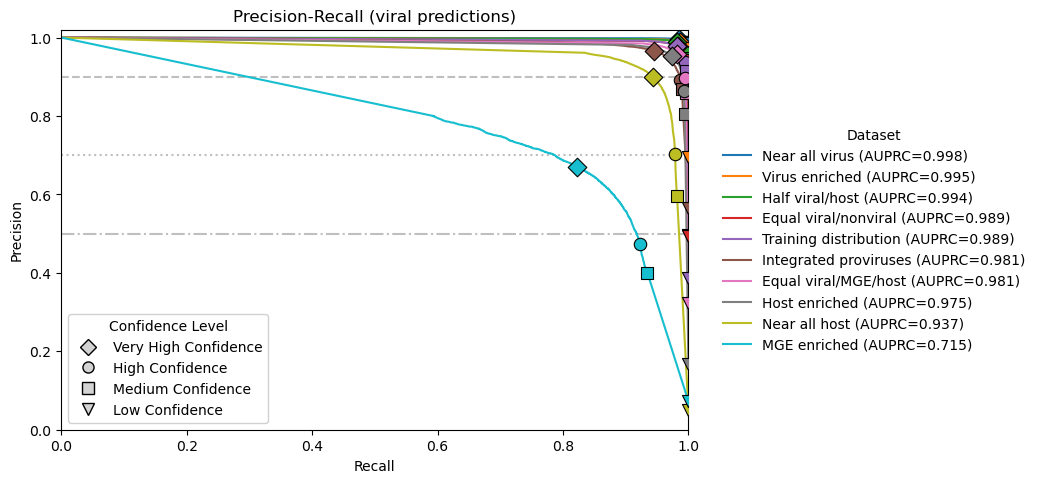

In [9]:
plot_pr_curves(model_predictions_with_labels, "Viral prob", "viral", "Precision-Recall (viral predictions)", points=viral_points, floor_lines=list(PRECISION_FLOORS["viral"].values()))
plt.show()

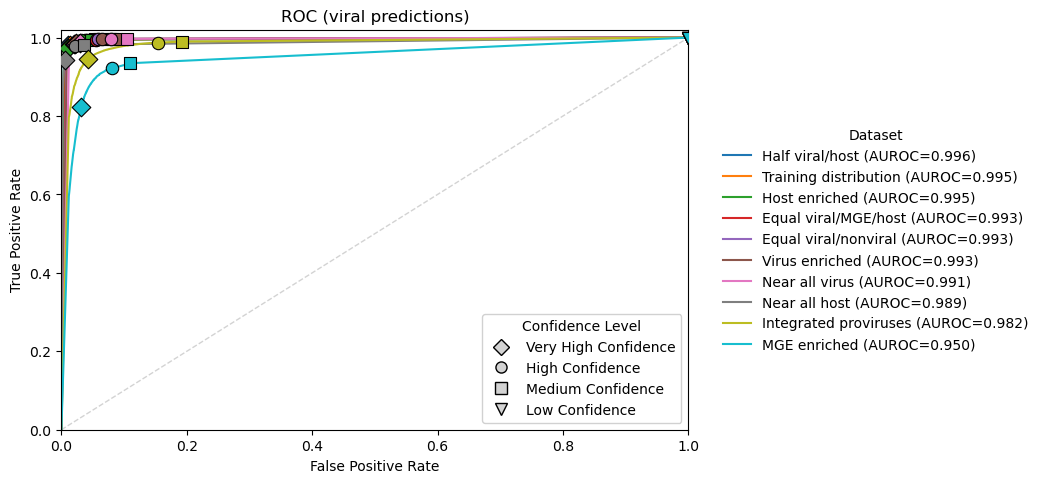

In [10]:
plot_roc_curves(model_predictions_with_labels, "Viral prob", "viral", "ROC (viral predictions)", points=viral_points)
plt.show()

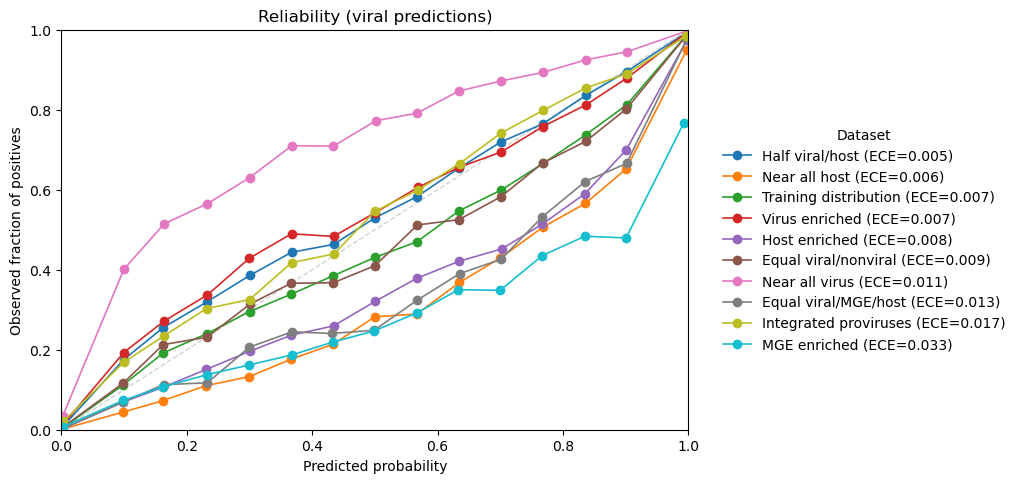

In [11]:
plot_reliability_curves(model_predictions_with_labels, "Viral prob", "viral", "Reliability (viral predictions)")
plt.show()

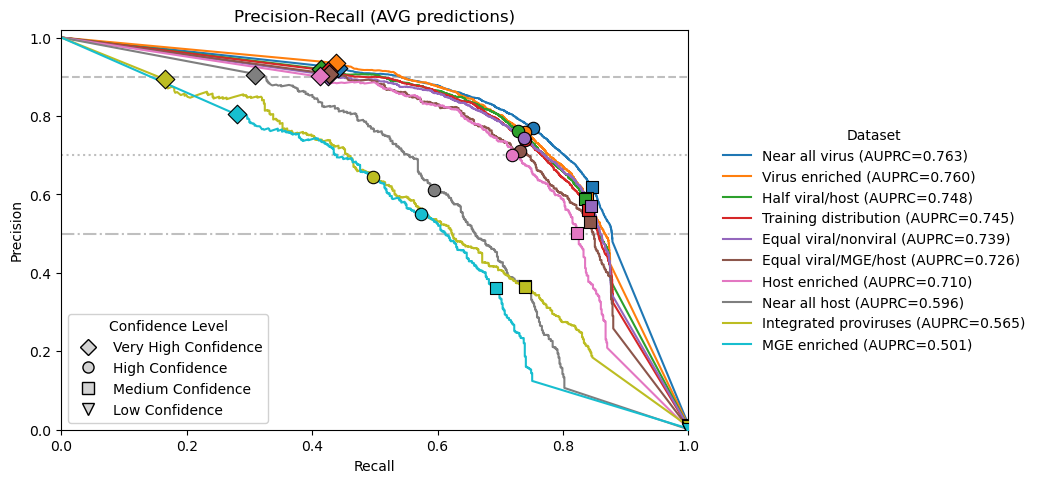

In [12]:
plot_pr_curves(model_predictions_with_labels, "eff_avg_prob", "eff_avg_label", "Precision-Recall (AVG predictions)", points=avg_points, floor_lines=list(PRECISION_FLOORS["AVG"].values()))
plt.show()

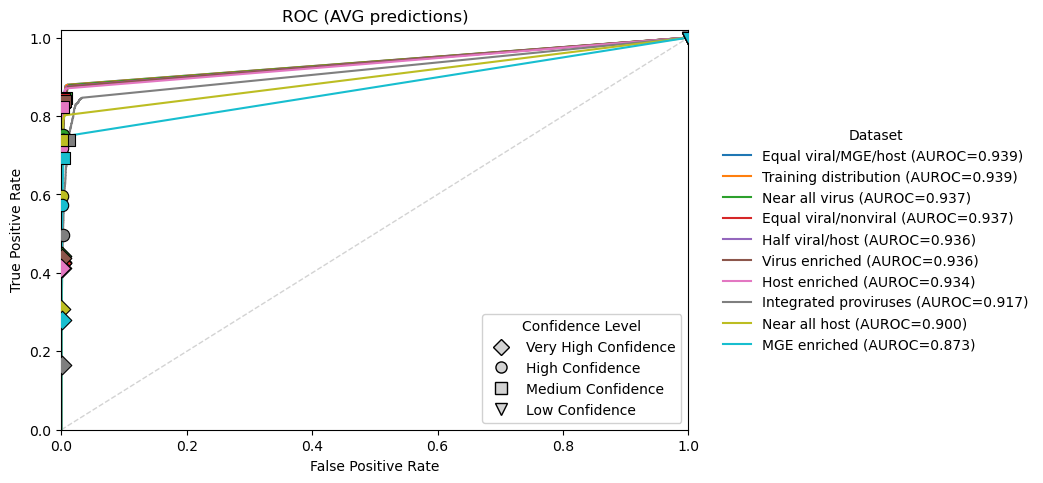

In [13]:
plot_roc_curves(model_predictions_with_labels, "eff_avg_prob", "eff_avg_label", "ROC (AVG predictions)", points=avg_points)
plt.show()

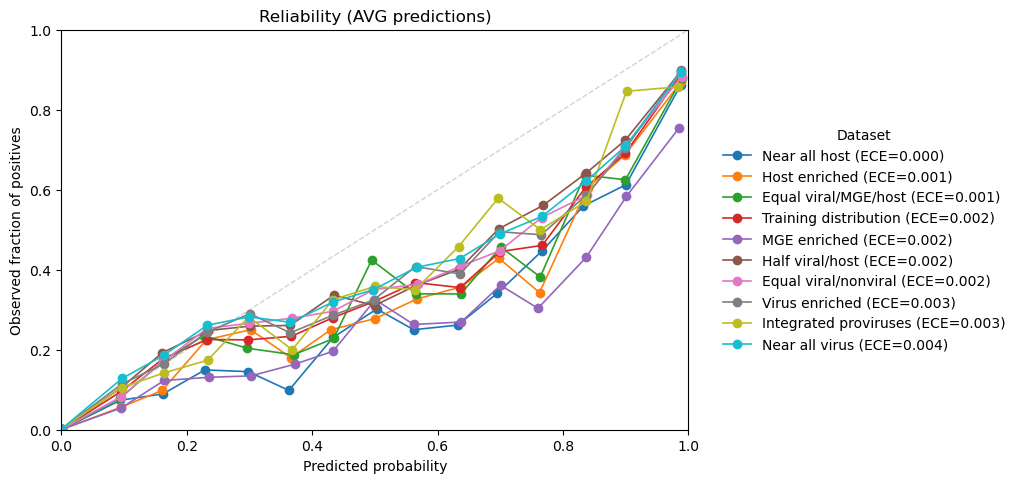

In [14]:
plot_reliability_curves(model_predictions_with_labels, "eff_avg_prob", "eff_avg_label", "Reliability (AVG predictions)")
plt.show()

### PR and ROC curves: AVG predictions without the AND gate

Same curves and calculations as the AVG section above, but using the raw AVG-like probability (`AVG-like prob`) and label (`AVG`) directly, without combining with the viral prediction.

In [15]:
# avg_raw_thresholds / avg_raw_points were computed in the threshold-selection cell above.
for c, t in avg_raw_thresholds.items():
    print(f"  {c:<22} t={t:.4f}")

  Very High Confidence   t=0.8900
  High Confidence        t=0.2010
  Medium Confidence      t=0.0340
  Low Confidence         t=0.0000


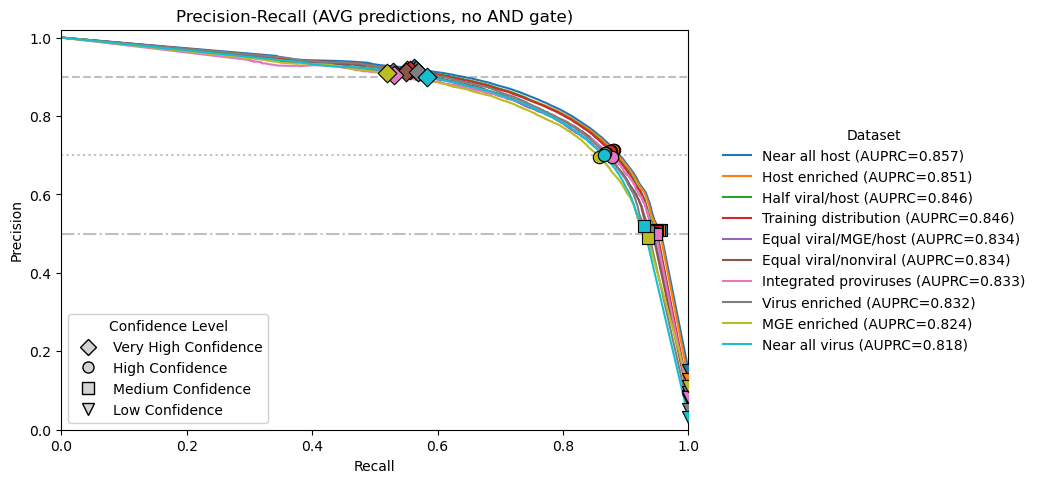

In [16]:
plot_pr_curves(model_predictions_with_labels, "AVG-like prob", "AVG", "Precision-Recall (AVG predictions, no AND gate)", points=avg_raw_points, floor_lines=list(PRECISION_FLOORS["AVG"].values()))
plt.show()

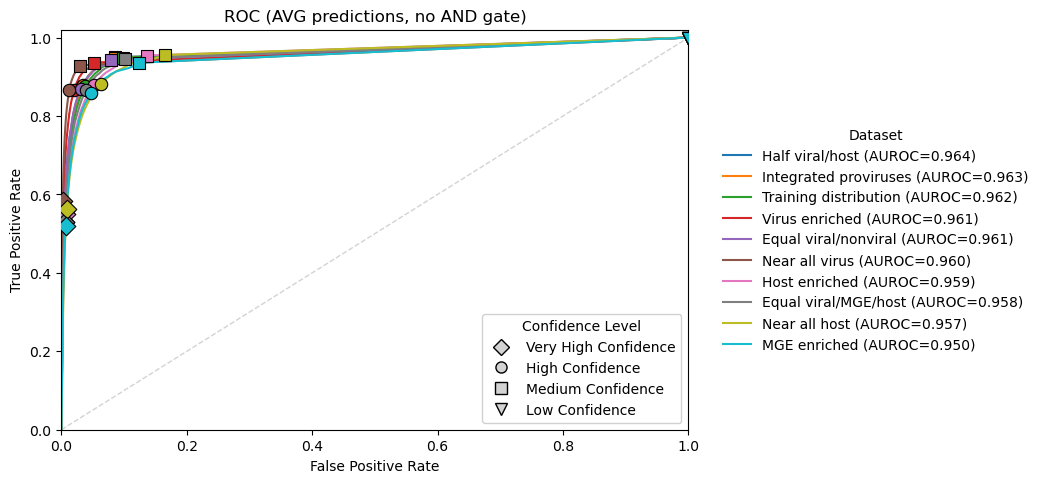

In [17]:
plot_roc_curves(model_predictions_with_labels, "AVG-like prob", "AVG", "ROC (AVG predictions, no AND gate)", points=avg_raw_points)
plt.show()

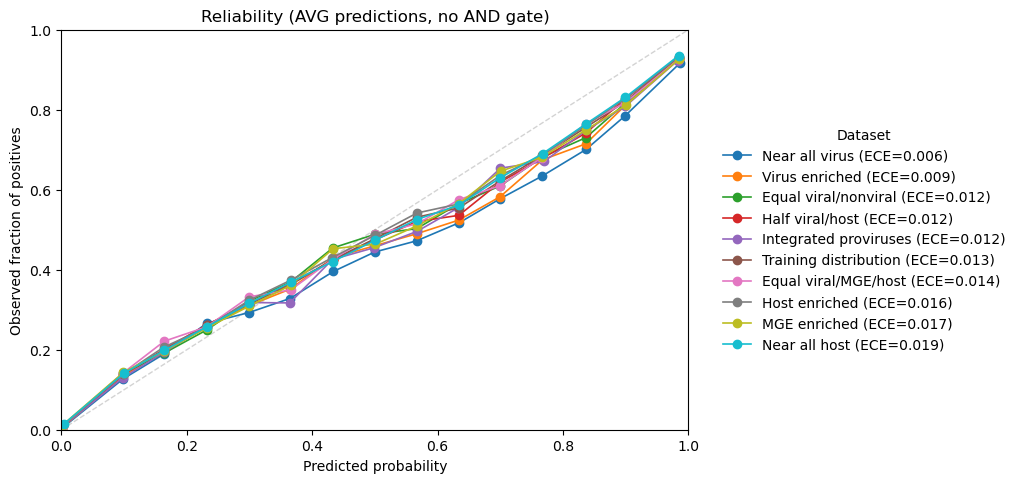

In [18]:
plot_reliability_curves(model_predictions_with_labels, "AVG-like prob", "AVG", "Reliability (AVG predictions, no AND gate)")
plt.show()

In [19]:
# AUPRC/AUROC for the no-AND-gate AVG predictions (display only; not written to files).
auc_summary_df(model_predictions_with_labels, "AVG-like prob", "AVG", "AVG (no AND gate)")

dataset,target,auprc,auroc
str,str,f64,f64
"""Equal viral/nonviral""","""AVG (no AND gate)""",0.834078,0.960669
"""Equal viral/MGE/host""","""AVG (no AND gate)""",0.834104,0.958424
"""Half viral/host""","""AVG (no AND gate)""",0.846175,0.963703
"""Host enriched""","""AVG (no AND gate)""",0.850898,0.959488
"""Training distribution""","""AVG (no AND gate)""",0.845859,0.96156
"""MGE enriched""","""AVG (no AND gate)""",0.824396,0.950303
"""Near all host""","""AVG (no AND gate)""",0.857294,0.957095
"""Near all virus""","""AVG (no AND gate)""",0.818217,0.960314
"""Integrated proviruses""","""AVG (no AND gate)""",0.833303,0.962715


### Save plot points and AUPRC/AUROC values

Include the AND-gated AVG (`eff_avg_prob`/`eff_avg_label`) predictions and the non-AND-gated predictions.

In [20]:
df_pr = pl.concat([
    pr_points_df(model_predictions_with_labels, "Viral prob",    "viral",         "viral",          marker_points=viral_points),
    pr_points_df(model_predictions_with_labels, "eff_avg_prob",  "eff_avg_label", "AVG (AND gate)", marker_points=avg_points),
    pr_points_df(model_predictions_with_labels, "AVG-like prob", "AVG",           "AVG",            marker_points=avg_raw_points),
])
df_pr


dataset,target,type,idx,recall,precision,confidence
str,str,str,i64,f64,f64,str
"""Equal viral/nonviral""","""viral""","""curve""",0,1.0,0.494313,null
"""Equal viral/nonviral""","""viral""","""curve""",1,0.996511,0.922889,null
"""Equal viral/nonviral""","""viral""","""curve""",2,0.996511,0.922893,null
"""Equal viral/nonviral""","""viral""","""curve""",3,0.996511,0.922898,null
"""Equal viral/nonviral""","""viral""","""curve""",4,0.996511,0.922903,null
…,…,…,…,…,…,…
"""Integrated proviruses""","""AVG""","""point""",null,1.0,0.082873,"""Low Confidence"""
"""Virus enriched""","""AVG""","""point""",null,0.568989,0.911924,"""Very High Confidence"""
"""Virus enriched""","""AVG""","""point""",null,0.866708,0.706338,"""High Confidence"""


In [21]:
df_roc = pl.concat([
    roc_points_df(model_predictions_with_labels, "Viral prob",    "viral",          "viral",          marker_points=viral_points),
    roc_points_df(model_predictions_with_labels, "eff_avg_prob",  "eff_avg_label",  "AVG (AND gate)", marker_points=avg_points),
    roc_points_df(model_predictions_with_labels, "AVG-like prob", "AVG",            "AVG",            marker_points=avg_raw_points),
])
df_roc


dataset,target,type,idx,fpr,tpr,confidence
str,str,str,i64,f64,f64,str
"""Equal viral/nonviral""","""viral""","""curve""",0,0.0,0.0,null
"""Equal viral/nonviral""","""viral""","""curve""",1,0.007823,0.931146,null
"""Equal viral/nonviral""","""viral""","""curve""",2,0.007823,0.931151,null
"""Equal viral/nonviral""","""viral""","""curve""",3,0.007823,0.931156,null
"""Equal viral/nonviral""","""viral""","""curve""",4,0.007823,0.931162,null
…,…,…,…,…,…,…
"""Integrated proviruses""","""AVG""","""point""",null,1.0,1.0,"""Low Confidence"""
"""Virus enriched""","""AVG""","""point""",null,0.003117,0.568989,"""Very High Confidence"""
"""Virus enriched""","""AVG""","""point""",null,0.020439,0.866708,"""High Confidence"""


In [22]:
df_auc = pl.concat([
    auc_summary_df(model_predictions_with_labels, "Viral prob",    "viral",         "viral"),
    auc_summary_df(model_predictions_with_labels, "eff_avg_prob",  "eff_avg_label", "AVG (AND gate)"),
    auc_summary_df(model_predictions_with_labels, "AVG-like prob", "AVG",           "AVG"),
])
df_auc

dataset,target,auprc,auroc
str,str,f64,f64
"""Equal viral/nonviral""","""viral""",0.989164,0.993362
"""Equal viral/MGE/host""","""viral""",0.980945,0.993414
"""Half viral/host""","""viral""",0.993791,0.995679
"""Host enriched""","""viral""",0.974904,0.994816
"""Training distribution""","""viral""",0.989007,0.994953
…,…,…,…
"""MGE enriched""","""AVG""",0.824396,0.950303
"""Near all host""","""AVG""",0.857294,0.957095
"""Near all virus""","""AVG""",0.818217,0.960314


In [23]:
df_thresholds = thresholds_df(
    ("viral",          viral_thresholds),
    ("AVG",            avg_raw_thresholds),
    ("AVG (AND gate)", avg_thresholds)
)
df_thresholds

target,confidence,threshold
str,str,f64
"""viral""","""Very High Confidence""",0.622
"""viral""","""High Confidence""",0.051
"""viral""","""Medium Confidence""",0.001
"""viral""","""Low Confidence""",0.0
"""AVG""","""Very High Confidence""",0.89
…,…,…
"""AVG""","""Low Confidence""",0.0
"""AVG (AND gate)""","""Very High Confidence""",0.956
"""AVG (AND gate)""","""High Confidence""",0.512


In [24]:
df_threshold_points = threshold_points_df(
    ("viral",          viral_points),
    ("AVG",            avg_raw_points),
    ("AVG (and gate)", avg_points),
)
df_threshold_points

dataset,target,confidence,precision,recall,fpr,tpr
str,str,str,f64,f64,f64,f64
"""Equal viral/nonviral""","""viral""","""Very High Confidence""",0.978011,0.982883,0.021601,0.982883
"""Equal viral/nonviral""","""viral""","""High Confidence""",0.942937,0.995443,0.058885,0.995443
"""Equal viral/nonviral""","""viral""","""Medium Confidence""",0.922889,0.996511,0.08139,0.996511
"""Equal viral/nonviral""","""viral""","""Low Confidence""",0.494313,1.0,1.0,1.0
"""Equal viral/MGE/host""","""viral""","""Very High Confidence""",0.959008,0.982362,0.020081,0.982362
…,…,…,…,…,…,…
"""Integrated proviruses""","""AVG (and gate)""","""Low Confidence""",0.008929,1.0,1.0,1.0
"""Virus enriched""","""AVG (and gate)""","""Very High Confidence""",0.934088,0.438568,0.000318,0.438568
"""Virus enriched""","""AVG (and gate)""","""High Confidence""",0.759488,0.739492,0.002408,0.739492


In [25]:
df_reliability = pl.concat([
    reliability_points_df(model_predictions_with_labels, "Viral prob",    "viral",         "viral"),
    reliability_points_df(model_predictions_with_labels, "AVG-like prob", "AVG",           "AVG"),
    reliability_points_df(model_predictions_with_labels, "eff_avg_prob",  "eff_avg_label", "AVG (AND gate)"),
])
df_reliability

dataset,target,idx,predicted_prob,observed_fraction,bin_count,ece
str,str,i64,f64,f64,i64,f64
"""Equal viral/nonviral""","""viral""",0,0.001579,0.005171,183538,0.009274
"""Equal viral/nonviral""","""viral""",1,0.098912,0.117108,2075,0.009274
"""Equal viral/nonviral""","""viral""",2,0.162346,0.212766,1410,0.009274
"""Equal viral/nonviral""","""viral""",3,0.231879,0.231189,917,0.009274
"""Equal viral/nonviral""","""viral""",4,0.301457,0.314685,715,0.009274
…,…,…,…,…,…,…
"""Virus enriched""","""AVG (AND gate)""",10,0.698652,0.494949,198,0.003009
"""Virus enriched""","""AVG (AND gate)""",11,0.765269,0.4875,240,0.003009
"""Virus enriched""","""AVG (AND gate)""",12,0.837118,0.586111,360,0.003009


In [26]:
PR_POINTS_OUT          = PST_TABLES_OUTDIR.joinpath("pst_pr_points.parquet")
ROC_POINTS_OUT         = PST_TABLES_OUTDIR.joinpath("pst_roc_points.parquet")
RELIABILITY_POINTS_OUT = PST_TABLES_OUTDIR.joinpath("pst_reliability_points.parquet")
AUC_SUMMARY_OUT        = PST_TABLES_OUTDIR.joinpath("pst_auc_summary.tsv")
THRESHOLDS_OUT         = PST_TABLES_OUTDIR.joinpath("pst_thresholds.tsv")
THRESHOLD_POINTS_OUT   = PST_TABLES_OUTDIR.joinpath("pst_threshold_points.tsv")

df_pr.write_parquet(PR_POINTS_OUT)
df_roc.write_parquet(ROC_POINTS_OUT)
df_reliability.write_parquet(RELIABILITY_POINTS_OUT)
df_auc.write_csv(AUC_SUMMARY_OUT, separator="\t")
df_thresholds.write_csv(THRESHOLDS_OUT, separator="\t")
df_threshold_points.write_csv(THRESHOLD_POINTS_OUT, separator="\t")